# Experiment 06 (Advanced): Advanced Logistic Regression & Classification Modeling
## Title: Comprehensive Analysis: Binary & Multiclass Classification (OvR/Multinomial), Regularized Classification (L1/L2), Decision Boundary Visualization, ROC-AUC, and Precision-Recall Curves

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Advanced Libraries & Setup Environment

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42) 
print("All necessary libraries have been imported successfully.")

All necessary libraries have been imported successfully.


### Step 2: Load & Inspect Breast Cancer Binary Classification Dataset

In [2]:
# Using the Breast Cancer Wisconsin dataset (real-world, open-access, built into sklearn)
# Target: 0 = malignant, 1 = benign (binary classification)
data = load_breast_cancer(as_frame=True)
df_cancer = data.frame

print("Shape of dataset: " , df_cancer.shape)
print("target Classes: " , dict(zip(data.target.unique(), data.target_names)))
df_cancer.head()

Shape of dataset:  (569, 31)
target Classes:  {np.int64(0): np.str_('malignant'), np.int64(1): np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Step 3: Regularized Logistic Regression Model Tuning (L1 & L2)

In [3]:
# Split the dataset for binary classification
X_cancer  = df_cancer.drop('target', axis=1)
y_cancer  = df_cancer['target']

X_tr, X_te, y_tr, y_te = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer)

scaler      = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

lr_l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=1000, random_state=42)
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000, random_state=42)

lr_l2.fit(X_tr_scaled, y_tr)
lr_l1.fit(X_tr_scaled, y_tr)

y_pred_l2 = lr_l2.predict(X_te_scaled)
y_prob_l2 = lr_l2.predict_proba(X_te_scaled)[:, 1]
y_pred_l1 = lr_l1.predict(X_te_scaled)
y_prob_l1 = lr_l1.predict_proba(X_te_scaled)[:, 1]

comparison = pd.DataFrame({
    'Model': ['L1 Regularized Logistic Regression', 'L2 Regularized Logistic Regression'],
    'Accuracy': [accuracy_score(y_te, y_pred_l1), accuracy_score(y_te, y_pred_l2)],
    'Precision': [precision_score(y_te, y_pred_l1), precision_score(y_te, y_pred_l2)],
    'Recall': [recall_score(y_te, y_pred_l1), recall_score(y_te, y_pred_l2)],
    'F1-Score': [f1_score(y_te, y_pred_l1), f1_score(y_te, y_pred_l2)]
})

print("\nBinary Logistic Regression Regularization Comparison:\n")
print(comparison.to_string(index=False))
print("\nClassification Report for L2 Model:\n")
print(classification_report(y_te, y_pred_l2, target_names=data.target_names))

coef_summary = pd.DataFrame({
    'Feature': X_cancer.columns,
    'L1 Coef': lr_l1.coef_.ravel(),
    'L2 Coef': lr_l2.coef_.ravel()
})
coef_summary['L1 Abs'] = coef_summary['L1 Coef'].abs()
coef_summary['L2 Abs'] = coef_summary['L2 Coef'].abs()

print("Top 10 Features by L2 Coefficient Magnitude:\n")
print(coef_summary.sort_values('L2 Abs', ascending=False).head(10)[['Feature', 'L1 Coef', 'L2 Coef']].to_string(index=False))
print("\nNon-zero L1 coefficients:", np.count_nonzero(lr_l1.coef_))

y_pred = y_pred_l2
y_prob = y_prob_l2

best_model_name = 'L2 Regularized Logistic Regression'


Binary Logistic Regression Regularization Comparison:

                             Model  Accuracy  Precision   Recall  F1-Score
L1 Regularized Logistic Regression  0.991228   0.986301 1.000000  0.993103
L2 Regularized Logistic Regression  0.982456   0.986111 0.986111  0.986111

Classification Report for L2 Model:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Top 10 Features by L2 Coefficient Magnitude:

             Feature   L1 Coef   L2 Coef
       worst texture -1.205456 -1.255088
        radius error -2.167842 -1.082965
worst concave points -1.705453 -0.953686
          worst area -3.529897 -0.947756
        worst radius -1.248721 -0.947616
      worst symmetry -0.663777 -0.939181
          area error 

### Step 4: Decision Boundary Visualization on 2D Synthetic Data

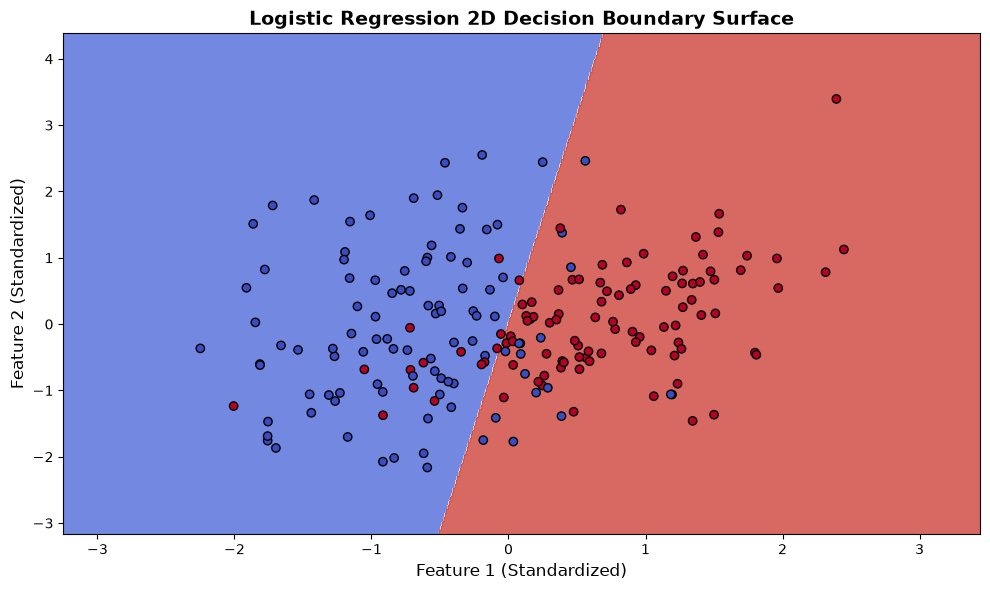

In [4]:
X_2d, y_2d = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
scaler_2d  = StandardScaler()
X_2d_sc    = scaler_2d.fit_transform(X_2d)

model_2d   = LogisticRegression().fit(X_2d_sc, y_2d)

x_min, x_max = X_2d_sc[:, 0].min() - 1, X_2d_sc[:, 0].max() + 1
y_min, y_max = X_2d_sc[:, 1].min() - 1, X_2d_sc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_2d_sc[:, 0], X_2d_sc[:, 1], c=y_2d, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
plt.title("Logistic Regression 2D Decision Boundary Surface", fontweight='bold', fontsize=14)
plt.xlabel("Feature 1 (Standardized)", fontsize=12)
plt.ylabel("Feature 2 (Standardized)", fontsize=12)
plt.tight_layout()
plt.show()

### Step 5: Confusion Matrix & ROC-AUC Curves 

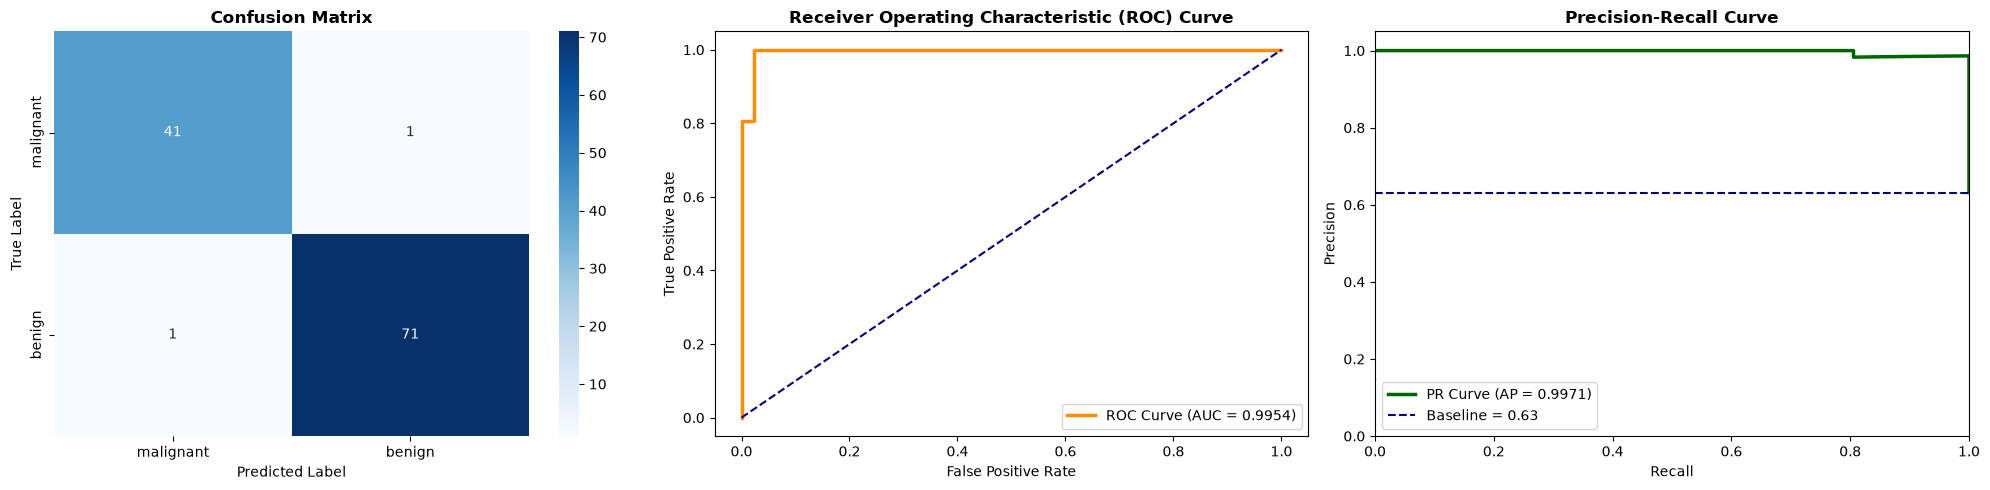

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=data.target_names, yticklabels=data.target_names)
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC Curve (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_te, y_prob)
pr_auc = average_precision_score(y_te, y_prob)
axes[2].plot(recall_vals, precision_vals, color="darkgreen", lw=2.5, label=f"PR Curve (AP = {pr_auc:.4f})")
axes[2].axhline(y=y_te.mean(), color="navy", linestyle="--", label=f"Baseline = {y_te.mean():.2f}")
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.show()

### Step 6: Multiclass Logistic Regression (OvR vs Multinomial)

In [6]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = train_test_split(X_iris, y_iris, test_size=0.25, random_state=42, stratify=y_iris)

scaler_iris = StandardScaler()
X_iris_tr_scaled = scaler_iris.fit_transform(X_iris_tr)
X_iris_te_scaled = scaler_iris.transform(X_iris_te)

ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
multi_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

ovr_model.fit(X_iris_tr_scaled, y_iris_tr)
multi_model.fit(X_iris_tr_scaled, y_iris_tr)

y_iris_pred_ovr = ovr_model.predict(X_iris_te_scaled)
y_iris_pred_multi = multi_model.predict(X_iris_te_scaled)

multiclass_summary = pd.DataFrame({
    'Model': ['OvR Logistic Regression', 'Multinomial Logistic Regression'],
    'Accuracy': [accuracy_score(y_iris_te, y_iris_pred_ovr), accuracy_score(y_iris_te, y_iris_pred_multi)],
    'Precision (weighted)': [precision_score(y_iris_te, y_iris_pred_ovr, average='weighted'), precision_score(y_iris_te, y_iris_pred_multi, average='weighted')],
    'Recall (weighted)': [recall_score(y_iris_te, y_iris_pred_ovr, average='weighted'), recall_score(y_iris_te, y_iris_pred_multi, average='weighted')],
    'F1-Score (weighted)': [f1_score(y_iris_te, y_iris_pred_ovr, average='weighted'), f1_score(y_iris_te, y_iris_pred_multi, average='weighted')]
})

print("Multiclass Logistic Regression Comparison:\n")
print(multiclass_summary.to_string(index=False))
print("\nOvR Classification Report:\n")
print(classification_report(y_iris_te, y_iris_pred_ovr, target_names=iris.target_names))
print("\nMultinomial Classification Report:\n")
print(classification_report(y_iris_te, y_iris_pred_multi, target_names=iris.target_names))


Multiclass Logistic Regression Comparison:

                          Model  Accuracy  Precision (weighted)  Recall (weighted)  F1-Score (weighted)
        OvR Logistic Regression  0.815789              0.823246           0.815789             0.817172
Multinomial Logistic Regression  0.921053              0.922619           0.921053             0.920936

OvR Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        12
  versicolor       0.75      0.69      0.72        13
   virginica       0.73      0.85      0.79        13

    accuracy                           0.82        38
   macro avg       0.83      0.82      0.82        38
weighted avg       0.82      0.82      0.82        38


Multinomial Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85 

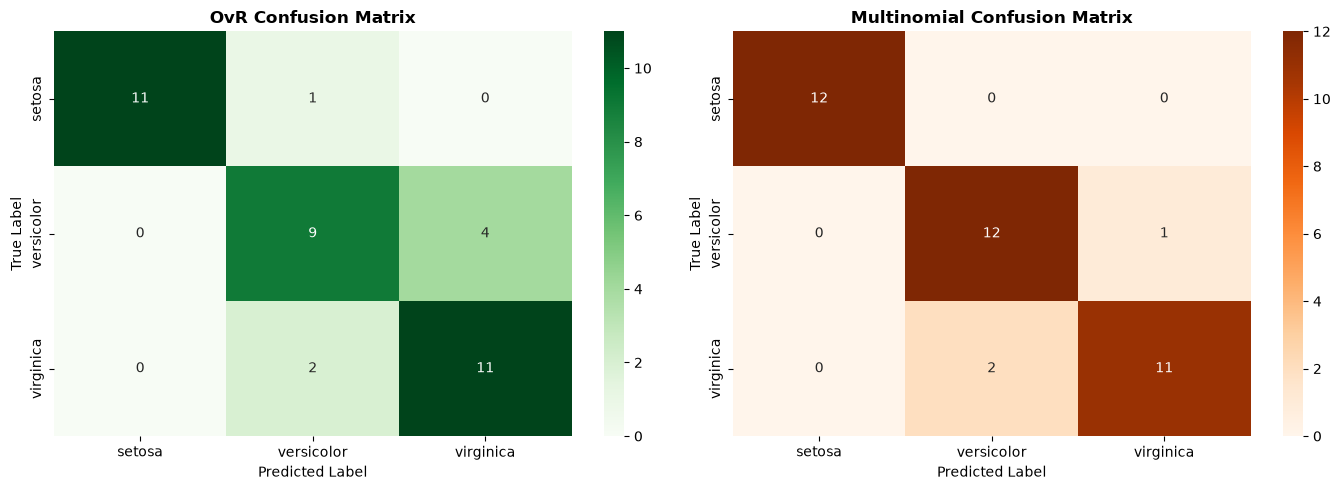

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ovr_cm = confusion_matrix(y_iris_te, y_iris_pred_ovr)
sns.heatmap(ovr_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0], xticklabels=iris.target_names, yticklabels=iris.target_names)
axes[0].set_title('OvR Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

multi_cm = confusion_matrix(y_iris_te, y_iris_pred_multi)
sns.heatmap(multi_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=iris.target_names, yticklabels=iris.target_names)
axes[1].set_title('Multinomial Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Step 7: Conclusion & Takeaways

1. **Binary Classification** now compares both L1 and L2 regularization and highlights the strongest features driving the prediction.
2. **ROC-AUC and Precision-Recall curves** give a stronger view of model quality than accuracy alone, especially for imbalanced or threshold-sensitive data.
3. **Multiclass Modeling** is covered with both OvR and multinomial logistic regression, so the notebook now matches the full scope in the title.

**Experiment Completed Successfully.**